---
title: Linear Regression Models fit to the US population data
---

The first topic in this course is "Multiple Linear Regression" for time series. Linear regression can be used in many ways for time series analysis, with basic applications in trend estimation and prediction/forecasting. We shall illustrate this today through the US population data. 

In [67]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

## US Population Dataset

This dataset is downloaded from FRED and gives monthly population of the United States in thousands. 

In [68]:
uspop = pd.read_csv('POPTHM_27Aug2026.csv')
print(uspop.head(10))
print(uspop.tail(10))

  observation_date  POPTHM
0       1959-01-01  175818
1       1959-02-01  176044
2       1959-03-01  176274
3       1959-04-01  176503
4       1959-05-01  176723
5       1959-06-01  176954
6       1959-07-01  177208
7       1959-08-01  177479
8       1959-09-01  177755
9       1959-10-01  178026
    observation_date  POPTHM
801       2025-10-01  342366
802       2025-11-01  342439
803       2025-12-01  342495
804       2026-01-01  342540
805       2026-02-01  342581
806       2026-03-01  342627
807       2026-04-01  342680
808       2026-05-01  342746
809       2026-06-01  342822
810       2026-07-01  342909


Let us set the index of each row to be the corresponding month, so the plots are easier to interpret. 

In [69]:
uspop['observation_date'] = pd.to_datetime(uspop['observation_date'])
uspop.set_index('observation_date', inplace = True)
print(uspop)

                  POPTHM
observation_date        
1959-01-01        175818
1959-02-01        176044
1959-03-01        176274
1959-04-01        176503
1959-05-01        176723
...                  ...
2026-03-01        342627
2026-04-01        342680
2026-05-01        342746
2026-06-01        342822
2026-07-01        342909

[811 rows x 1 columns]


Here is a plot of the dataset. 

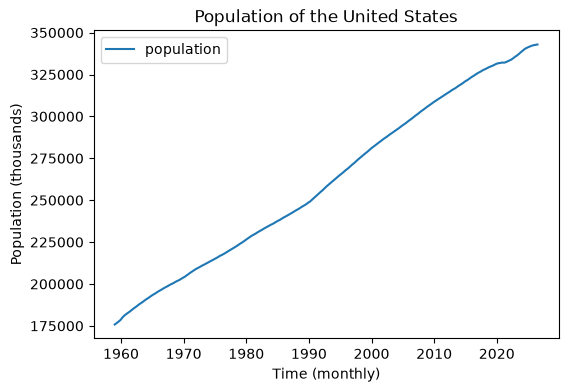

In [70]:
plt.figure(figsize=(6, 4))
plt.plot(uspop['POPTHM'], label = "population")
plt.xlabel("Time (monthly)")
plt.ylabel("Population (thousands)")
plt.title("Population of the United States")
plt.legend()
plt.show()

Based on this dataset, suppose we want to answer the following prediction (or forecasting) question: what would be the population of the United States in July 2040? The last month in the observed data is July 2026 (i.e., month $n$ corresponds to July 2026), so July 2040 would be month $n + 14*12 = n + 168$. 

Let us attempt to answer this question by fitting simple models based on linear regression to the observed data. Before fitting models, let us first note some available answers to this question. There are population projections available from the Census Bureau, as well as from the United Nations. The Census Bureau projection for the US population in July 2040 is 355.309 million. The UN projection is 370.209 million.

Let $y_t$ denote the population of the United States for month $t$. The first model is simply: $y_t = \beta_0 + \beta_1 t + \epsilon_t$. This is just linear regression with time $t$ as the covariate. 

### Model 1: $y_t = \beta_0 + \beta_1 t + \epsilon_t$

Parameter interpretation: $\beta_0$: population at time 0 (note that the data starts from January 1959 so time 0 refers to December 1958) and $\beta_1$: change in population for each additional month. 

We fit this model to the data using the following code. 

In [71]:
#Model 1: y_t = beta_0 + beta_1 t + \epsilon_t
#y_t is the population at time t
y = uspop['POPTHM']
n = len(y)
x = np.arange(1, n + 1)
X = np.column_stack([np.ones(n),x])

md1 = sm.OLS(y, X).fit()
print(md1.summary())

                            OLS Regression Results                            
Dep. Variable:                 POPTHM   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 2.794e+05
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:06:34   Log-Likelihood:                -7554.3
No. Observations:                 811   AIC:                         1.511e+04
Df Residuals:                     809   BIC:                         1.512e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.746e+05    189.054    923.472      0.0

The output above consists of many different things. We shall see how some of these numbers are calculated in the next couple of lectures. The main output is the estimates of $\beta_0$ and $\beta_1$ (these are given by the 'coef' column above). 

In [72]:
print(md1.params)

const    174585.548486
x1          213.215735
dtype: float64


After fitting a model, it is a good idea to look at the plot of the data along with the 'fitted values' and also the 'residuals'. Fitted values are defined by: 
\begin{align*}
   \hat{\beta}_0 + \hat{\beta}_1 t 
\end{align*}
for $t = 1, \dots, n$. 

Residuals are defined by: 
\begin{align*}
   y_t - \hat{\beta}_0 - \hat{\beta}_1 t. 
\end{align*}
Residuals represent the part of the data that is not explained by the model equation. 

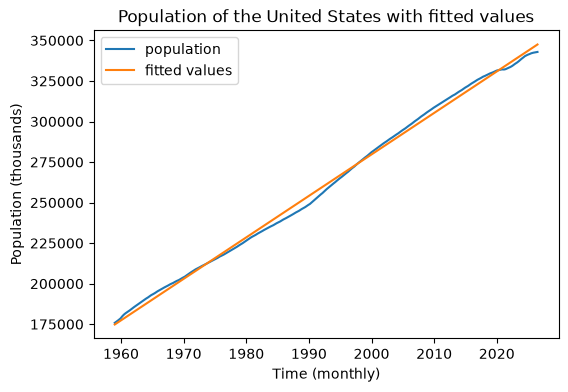

In [73]:
#Plotting data along with residuals
plt.figure(figsize=(6, 4))
plt.plot(y, label = "population")
plt.plot(md1.fittedvalues, label = "fitted values")
plt.xlabel("Time (monthly)")
plt.ylabel("Population (thousands)")
plt.title("Population of the United States with fitted values")
plt.legend()
plt.show()

The fitted values plot suggests that the line is explaining the data well. Note though that the $y$-axis goes from 175K to 350K which covers a wide range, so even small changes in this plot can indicate big numerical departures. 

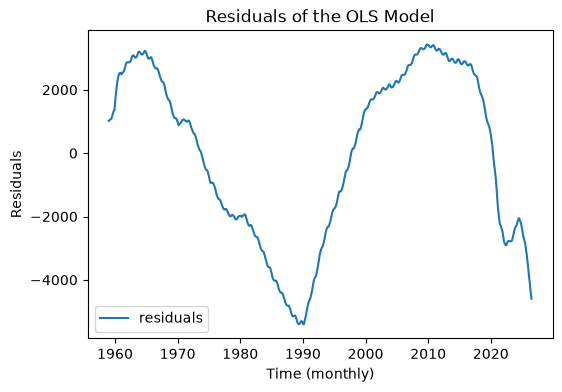

In [74]:
#Plotting residuals: 
plt.figure(figsize=(6, 4))
plt.plot(md1.resid, label = "residuals")
plt.xlabel("Time (monthly)")
plt.ylabel("Residuals")
plt.title("Residuals of the OLS Model")
plt.legend()
plt.show()

All the recent residuals are negative which means that the fitted line takes higher values compared to the actual observations. From here, we can perhaps guess that future predictions will also be on the larger side. 

There is a lot of structure in the residuals which indicates that more modeling on the residuals is necessary.

Here is how this fitted model can be used to predict the population in July 2040. 

In [76]:
#Prediction for time t = n + 168 (July 2040):
n = len(y)
i = n+168
prediction = md1.get_prediction([1, i])
print("Mean prediction for July 2040:", prediction.predicted_mean)

Mean prediction for July 2040: [383323.7529835]


We are getting a prediction of 383.323 million which is quite a bit higher than the Census Bureau as well as the UN predictions. Below we plot the predictions along with the original dataset. 

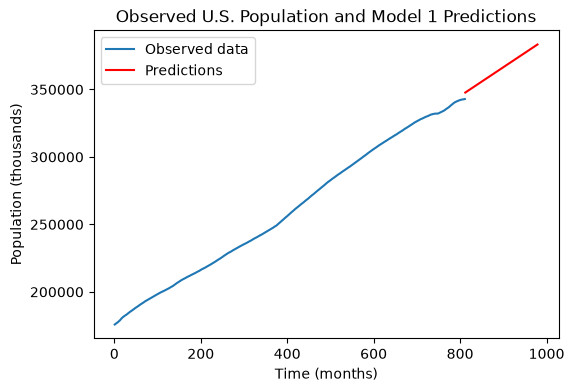

In [77]:
# Predict the next 168 monthly observations
r = 168
x_future = np.arange(n + 1, n + r + 1)
X_future = np.column_stack([
    np.ones(r),
    x_future
])
y_future = md1.predict(X_future)
plt.figure(figsize=(6, 4))
plt.plot(x, y, label="Observed data")
plt.plot(x_future, y_future, label="Predictions", color = 'red')
plt.xlabel("Time (months)")
plt.ylabel("Population (thousands)")
plt.title("Observed U.S. Population and Model 1 Predictions")
plt.legend()
plt.show()

Notice the small jump between where the data end, and the predictions. 

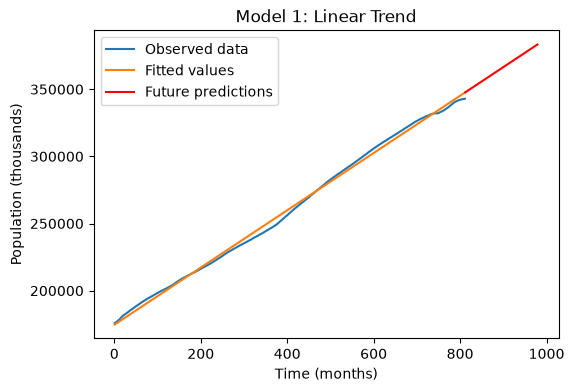

In [78]:
plt.figure(figsize=(6, 4))
plt.plot(x, y, label="Observed data")
plt.plot(x, md1.fittedvalues, label="Fitted values")
plt.plot(x_future, y_future, label="Future predictions", color = 'red')
plt.xlabel("Time (months)")
plt.ylabel("Population (thousands)")
plt.title("Model 1: Linear Trend")
plt.legend()

plt.show()

### Model Two: $\log y_t = \beta_0 + \beta_1 t + \epsilon_t$

Now we fit the line to the logarithms $\log y_t = \beta_0 + \beta_1 t + \epsilon_t$. Here is the interpretation of the parameters: $\beta_0$: log-population at time 0, and $\beta_1$: change in log-population from one month to the next. This change is given by: 
\begin{align*}
   \log y_t - \log y_{t-1} = \log \frac{y_t}{y_{t-1}} \approx \frac{y_t - y_{t-1}}{y_{t-1}}. 
\end{align*}
So therefore $100 \times \beta_1$ is the percent change in population from one month to the next. In other words, $100 \times \beta_1$ is the monthly population growth rate (expressed as a percentage). We can also say that $100 \times \beta_1 \times 12$ is the annual population growth rate (expressed as a percentage). 

In [79]:
#Model 2: $\log y_t = \beta_0 + \beta_1 t + \epsilon_t$. 
ylog = np.log(y)
mdlog = sm.OLS(ylog, X).fit()
print(mdlog.summary())

                            OLS Regression Results                            
Dep. Variable:                 POPTHM   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                 1.370e+05
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:17:25   Log-Likelihood:                 2257.3
No. Observations:                 811   AIC:                            -4511.
Df Residuals:                     809   BIC:                            -4501.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.1164      0.001   1.15e+04      0.0

The estimate of $\beta_1$ is $0.0008$. This means that for each additional month, $\log y_t$ increases by 0.0008. This implies that the growth rate of the population is 0.08% each month, or $12 * 0.08 = 0.96%$ annually. So, according to this model, the estimate of the annual growth rate of the US population is 0.96%. 

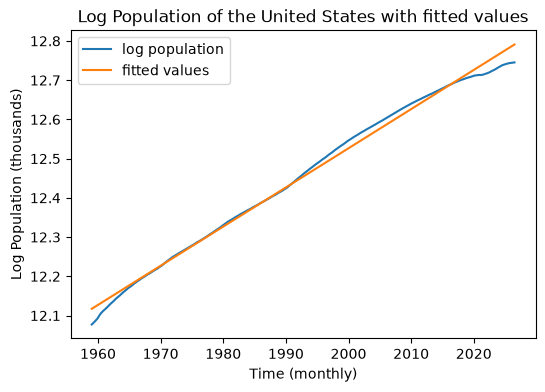

In [81]:
#Plotting fitted values and residuals:
plt.figure(figsize=(6, 4))
plt.plot(ylog, label = "log population")
plt.plot(mdlog.fittedvalues, label = "fitted values")
plt.xlabel("Time (monthly)")
plt.ylabel("Log Population (thousands)")
plt.title("Log Population of the United States with fitted values")
plt.legend()
plt.show()

The fitted values are reasonably close to the actual data, but in recent years, there is a slowdown in the growth. So predictions will probably be higher than what they should be. 

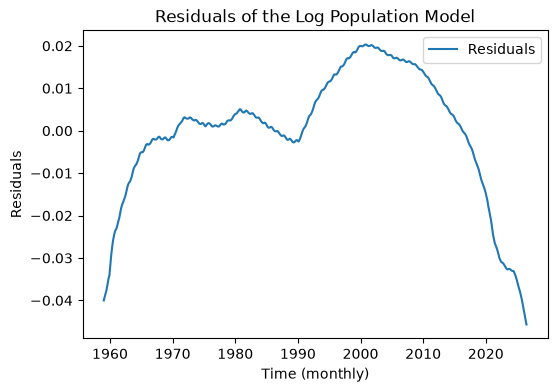

In [82]:
#Plotting residuals: 
plt.figure(figsize=(6, 4))
plt.plot(mdlog.resid, label="Residuals")
plt.xlabel("Time (monthly)")
plt.ylabel("Residuals")
plt.title("Residuals of the Log Population Model")
plt.legend()
plt.show()


Residuals are negative in the recent past (as in the case of Model 1). Also there is a lot of structure in the residuals. 

In [84]:
#Prediction for time t = n + 168 (July 2040):
n = len(ylog)
i = n+168
prediction_log = mdlog.get_prediction([1, i])
print("Mean prediction of log-population for July 2040 (log model):", prediction_log.predicted_mean)
print("Mean prediction of population for July 2040 (log model):", np.exp(prediction_log.predicted_mean))


Mean prediction of log-population for July 2040 (log model): [12.93062718]
Mean prediction of population for July 2040 (log model): [412762.30604638]


This is not a good prediction because the growth rate has significantly slowed down in recent years (while this model assumes constant growth rate throughout). 

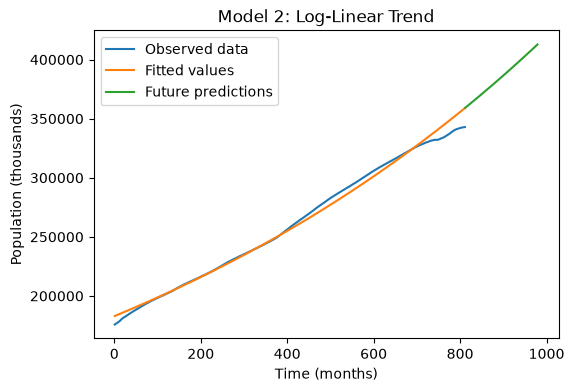

Prediction 168 months ahead: 412762.30604638177


In [85]:
# Predict the next 168 monthly observations
r = 168

# Future time points: n+1, ..., n+168
x_future = np.arange(n + 1, n + r + 1)

# Design matrix for future observations
X_future = np.column_stack([
    np.ones(r),
    x_future
])

# Fitted and predicted values on the log scale
ylog_fitted = mdlog.predict(X)
ylog_future = mdlog.predict(X_future)

# Convert back to population scale
y_fitted = np.exp(ylog_fitted)
y_future = np.exp(ylog_future)

# Plot observed data, fitted values, and future predictions
plt.figure(figsize=(6, 4))

plt.plot(x, y, label="Observed data")
plt.plot(x, y_fitted, label="Fitted values")
plt.plot(x_future, y_future, label="Future predictions")

plt.xlabel("Time (months)")
plt.ylabel("Population (thousands)")
plt.title("Model 2: Log-Linear Trend")
plt.legend()

plt.show()

# Prediction 168 months ahead
print("Prediction 168 months ahead:", y_future[-1])

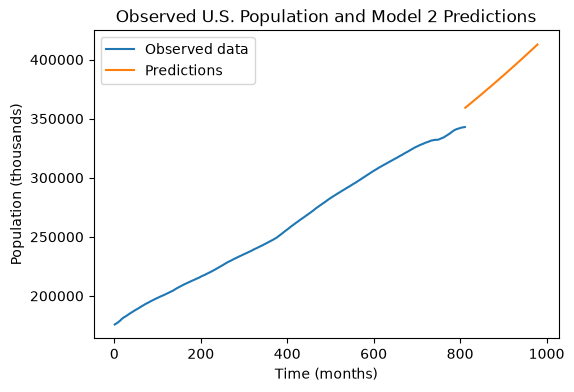

In [86]:
plt.figure(figsize=(6, 4))

plt.plot(x, y, label="Observed data")
plt.plot(x_future, y_future, label="Predictions")

plt.xlabel("Time (months)")
plt.ylabel("Population (thousands)")
plt.title("Observed U.S. Population and Model 2 Predictions")
plt.legend()

plt.show()

### Model 3: $\log y_t = \beta_0 + \beta_1 t + \beta_2 t^2 + \epsilon_t$

$\log y_t = \beta_0 + \beta_1 t + \beta_2 t^2 + \epsilon_t$. The growth rate now is $d \log y_t/dt = \beta_1+ 2 \beta_2 t$. So this allows the growth rate to change with $t$ (we would expect $\beta_2$ to be negative which would explain the decaying growth rate). 

In [88]:
# Model 3: $\log y_t = \beta_0 + \beta_1 t + \beta_2 t^2 + \epsilon_t$:
n = len(ylog)
x = np.arange(1, n + 1)
X = np.column_stack([np.ones(n),x, x ** 2])
md3 = sm.OLS(ylog, X).fit()
print(md3.summary())


                            OLS Regression Results                            
Dep. Variable:                 POPTHM   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 2.202e+05
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:25:10   Log-Likelihood:                 2729.6
No. Observations:                 811   AIC:                            -5453.
Df Residuals:                     808   BIC:                            -5439.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.0885      0.001   1.37e+04      0.0

Indeed the estimate of $\beta_2$ is negative. 

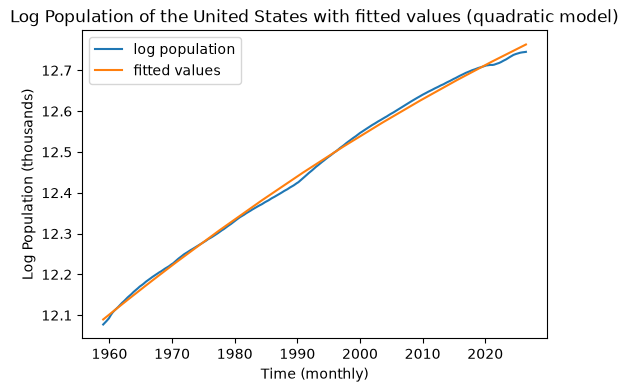

In [89]:
#Plotting the fitted values from the model
plt.figure(figsize=(6, 4))
plt.plot(ylog, label = "log population")
plt.plot(md3.fittedvalues, label = "fitted values")
plt.xlabel("Time (monthly)")
plt.ylabel("Log Population (thousands)")
plt.title("Log Population of the United States with fitted values (quadratic model)")
plt.legend()
plt.show()

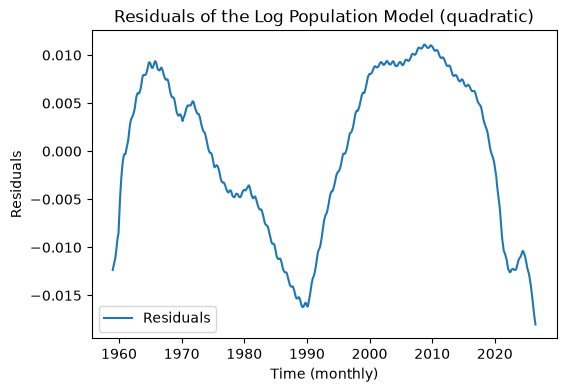

In [90]:
#Plotting residuals:
plt.figure(figsize=(6, 4))
plt.plot(md3.resid, label="Residuals")
plt.xlabel("Time (monthly)")
plt.ylabel("Residuals")
plt.title("Residuals of the Log Population Model (quadratic)")
plt.legend()
plt.show()

Note that the scale of the residuals is now  smaller than the residuals for model 2. 

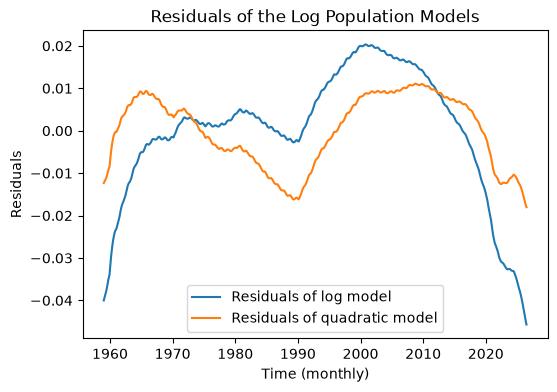

In [91]:
#Plotting both model 2 and model 3 residuals in one plot:
plt.figure(figsize=(6, 4))
plt.plot(mdlog.resid, label="Residuals of log model")
plt.plot(md3.resid, label="Residuals of quadratic model")
plt.xlabel("Time (monthly)")
plt.ylabel("Residuals")
plt.title("Residuals of the Log Population Models")
plt.legend()
plt.show()

In [92]:
#Prediction of log-population (and population) for time t = n + 168 (July 2040) using Model 3:
n = len(y)
i = n+168
predicted_population_july_2040_quadratic = md3.get_prediction([1, i, i**2])
print("Mean prediction of log-population for July 2040 (quadratic model):", predicted_population_july_2040_quadratic.predicted_mean)
print("Mean prediction of population for July 2040 (quadratic model):", np.exp(predicted_population_july_2040_quadratic.predicted_mean))


Mean prediction of log-population for July 2040 (quadratic model): [12.86138429]
Mean prediction of population for July 2040 (quadratic model): [385148.51545984]


This prediction is still on the higher side but not as bad as the predictions for model two. 

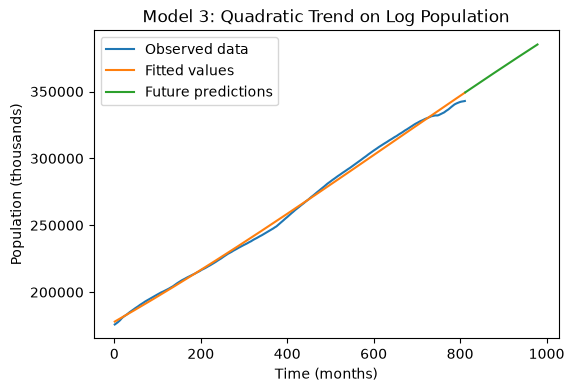

In [93]:
# Predict the next 168 monthly observations
r = 168

# Future time points: n+1, ..., n+168
x_future = np.arange(n + 1, n + r + 1)

# Design matrix for future observations
X_future = np.column_stack([
    np.ones(r),
    x_future,
    x_future ** 2
])

# Fitted and predicted values on the log scale
ylog_fitted = md3.predict(X)
ylog_future = md3.predict(X_future)

# Convert back to population scale
y_fitted = np.exp(ylog_fitted)
y_future = np.exp(ylog_future)

# Plot observed data, fitted values, and future predictions
plt.figure(figsize=(6, 4))

plt.plot(x, y, label="Observed data")
plt.plot(x, y_fitted, label="Fitted values")
plt.plot(x_future, y_future, label="Future predictions")

plt.xlabel("Time (months)")
plt.ylabel("Population (thousands)")
plt.title("Model 3: Quadratic Trend on Log Population")
plt.legend()

plt.show()

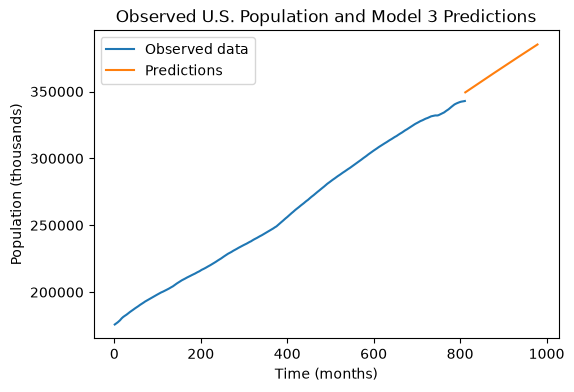

In [94]:
plt.figure(figsize=(6, 4))
plt.plot(x, y, label="Observed data")
plt.plot(x_future, y_future, label="Predictions")
plt.xlabel("Time (months)")
plt.ylabel("Population (thousands)")
plt.title("Observed U.S. Population and Model 3 Predictions")
plt.legend()
plt.show()

The predictions from all three models above share one undesirable feature: there is a noticeable jump between the most recent observed data point and the first predicted value. This is not very plausible, since there is little reason to expect the U.S. population in August 2026 to be substantially larger than the observed population in July 2026.

The next set of models is designed to avoid this issue. In these models, future population predictions are anchored at the most recently observed population, namely the July 2026 value, and evolve from that benchmark.

### Model 4: Modeling growth rate

This model directly works with the monthly growth rates (defined by $g_t$ below) as opposed to working with $y_t$ or $\log y_t$. 
\begin{align*}
   g_t = \log y_t - \log y_{t-1}. 
\end{align*}
Our model is: 
\begin{align*}
   g_t = \beta_0 + \beta_1 t + \epsilon_t
\end{align*}

The key point is that forecasting the growth rates forces the future
population path to be built starting from the last observed population
value.

Suppose the last observed population is $y_n$, corresponding to July
2026. Since
\begin{align*}
    g_t = \log y_t - \log y_{t-1},
\end{align*}
we can rewrite this as
\begin{align*}
    \log y_t = \log y_{t-1} + g_t.
\end{align*}

After fitting the model
\begin{align*}
    g_t = \beta_0 + \beta_1 t + \epsilon_t,
\end{align*}
the forecast for the next month's growth rate is
\begin{align*}
    \widehat{g}_{n+1}
    =
    \widehat{\beta}_0
    +
    \widehat{\beta}_1(n+1).
\end{align*}

The August 2026 population forecast is then constructed as
\begin{align*}
    \log \widehat{y}_{n+1}
    =
    \log y_n + \widehat{g}_{n+1},
\end{align*}
or equivalently,
\begin{align*}
    \widehat{y}_{n+1}
    =
    y_n \exp\left(\widehat{g}_{n+1}\right).
\end{align*}

Thus, the forecast explicitly starts from the observed July 2026
population $y_n$. Since monthly population growth rates are typically
quite small, $\exp(\widehat{g}_{n+1})$ will usually be close to $1$.
Consequently,
\begin{align*}
    \widehat{y}_{n+1} \approx y_n,
\end{align*}
with the difference corresponding to approximately one month's
predicted population growth.

For forecasts further into the future, we have
\begin{align*}
    \log \widehat{y}_{n+h}
    =
    \log y_n
    +
    \sum_{j=1}^{h} \widehat{g}_{n+j},
\end{align*}
and therefore
\begin{align*}
    \widehat{y}_{n+h}
    =
    y_n
    \exp\left(
        \sum_{j=1}^{h} \widehat{g}_{n+j}
    \right).
\end{align*}

Thus, every future forecast is anchored at the last observed population
value $y_n$.

By contrast, if we directly fit a model such as
\begin{align*}
    y_t = \beta_0 + \beta_1 t + \epsilon_t
\end{align*}
or
\begin{align*}
    \log y_t = \beta_0 + \beta_1 t + \epsilon_t,
\end{align*}
the fitted regression line is not required to pass through the final
observation $y_n$. Consequently, the extrapolated value at time $n+1$
can lie noticeably above or below the last observed population value.
This can create an artificial-looking jump between the last observation
and the first prediction.

The growth-rate model avoids this problem because the August 2026
forecast is obtained by starting with the actual July 2026 population
and applying exactly one month's predicted growth. Notice that the model
does not force the August prediction to equal the July population.
Rather, it forces the forecast to start from the July population and
then evolve according to the predicted monthly growth rates.

The code below fits this linear regression model on the growth rates. 

In [95]:
g = np.diff(ylog)
x = np.arange(1, len(g) + 1)
X = np.column_stack([np.ones(len(g)), x])
md4 = sm.OLS(g, X).fit()
print(md4.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.448
Model:                            OLS   Adj. R-squared:                  0.448
Method:                 Least Squares   F-statistic:                     656.5
Date:                Tue, 01 Sep 2026   Prob (F-statistic):          1.91e-106
Time:                        19:31:00   Log-Likelihood:                 5735.4
No. Observations:                 810   AIC:                        -1.147e+04
Df Residuals:                     808   BIC:                        -1.146e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0011   1.43e-05     79.733      0.0

Below we plot the fitted values on the growth rates data $g_t$. 

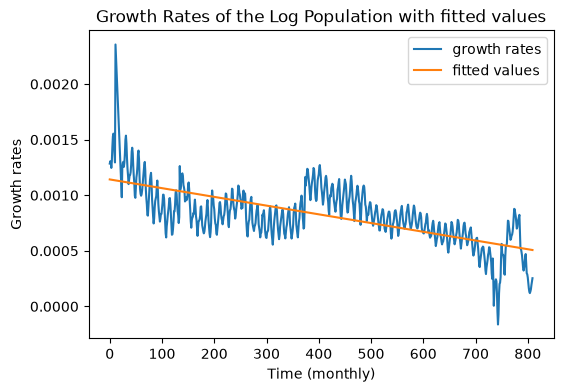

In [112]:
#Plotting growth rates and fitted values: 
plt.figure(figsize=(6, 4))
plt.plot(g, label = "growth rates")
plt.plot(md4.fittedvalues, label = "fitted values")
plt.xlabel("Time (monthly)")
plt.ylabel("Growth rates")
plt.title("Growth Rates of the Log Population with fitted values")
plt.legend()
plt.show()

There is a clear declining trend on the growth rates that is captured by the fitted regression line. There is a richer structure in the growth rates though which the single regression line does not fully capture; so there is a scope for more sophisticated models that can be fit to the growth rates data. 

Below are the residuals obtained after fitting the regression line to the growth rates. 

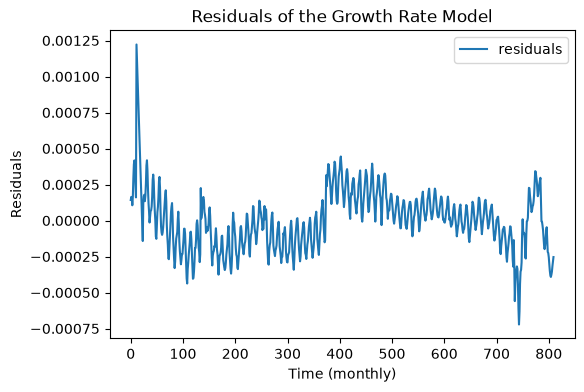

In [113]:
#Plotting residuals: 
plt.figure(figsize=(6, 4))
plt.plot(md4.resid, label = "residuals")
plt.xlabel("Time (monthly)")
plt.ylabel("Residuals")
plt.title("Residuals of the Growth Rate Model")
plt.legend()
plt.show()

There are still some linear patterns in these residuals which can be potentially explained by more sophisticated models. 

Here is the prediction for this model for the population in July 2040. 

In [114]:
n = len(ylog)
x_future = np.arange(n, n + 168)
X_future = np.column_stack([np.ones(168), x_future])

g_pred = md4.predict(X_future)
y_pred = y.iloc[-1] * np.exp(g_pred.sum())

print(y_pred)

369282.4340955185


This prediction is closer to the United Nations projection of 370.209 million. 

Below is the plot of the predictions along with the observed dataset. It can be clearly seen that there is no jump between where the observed data ends and the predictions start. 

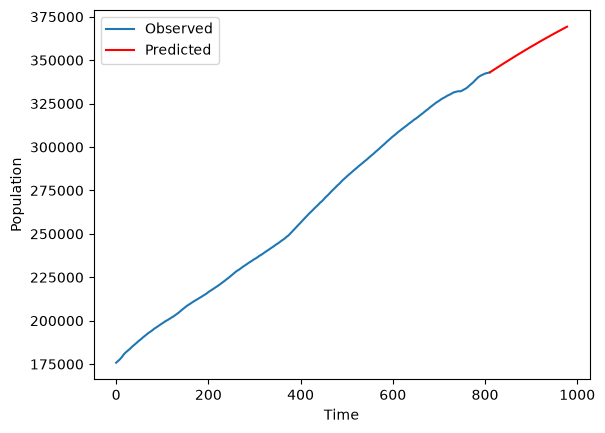

In [115]:
y_future_md4 = y.iloc[-1] * np.exp(np.cumsum(g_pred))

plt.plot(np.arange(n), y, label="Observed")
plt.plot(np.arange(n, n + 168), y_future_md4, label="Predicted", color = 'red')

plt.xlabel("Time")
plt.ylabel("Population")
plt.legend()
plt.show()

### Model 5: $g_t = \beta_0 + \beta_1 t + \beta_2 (t - c)_+ + \epsilon_t$. 

Here we modify model 4 by adding one more covariate in regression $(t - c)_+$ leading to the model: 
\begin{align*}
   g_t = \beta_0 + \beta_1 t + \beta_2 (t - c)_+ + \epsilon_t. 
\end{align*}
The term $(t - c)_+$ simply equals $\max(t - c, 0)$. This means that $(t - c)_+$ equals $t - c$ if $t \geq c$ and $(t - c)_+$ equals 0 when $t \leq c$. Another way of writing $(t - c)_+$ is $\text{ReLU}(t - c)$. Here $\text{ReLU}(x) = x_+ = x I\{x \geq 0\}$ (where $I\{x \geq 0\}$ equals 1 if $x \geq 0$ and 0 if $x \leq 0$). ReLU is a terminology heavily used in modern machine learning and it stands for Rectified Linear Unit. 

This regression fits a continuous function consisting of two straight lines to the data. Before the time point given by $c$, the fitted slope is $\beta_1$. After $c$, the fitted slope is $\beta_1+\beta_2$. The two line segments join continuously at $c$.

If $c$ is a known time point, then this is an example of multiple linear regression with covariates $1$, $t$, and $(t-c)_+$. When $c$ is also unknown, we can treat this is as a nonlinear regression problem. We shall look at estimation of $c$ in detail later. The method we shall use is: 

1. try each candidate month $c$;
2. fit the corresponding linear regression;
3. record its residual sum of squares (RSS);
4. choose the candidate with the smallest RSS.

We shall look at the above procedure in detail later. Here is the code for implementing this method to obtain an estimate of $c$. 

In [116]:
# Monthly log growth rates
g = ylog.diff().dropna()

t = np.arange(1, len(g) + 1)

# RSS for a given change point c
def rss(c):
    X = np.column_stack([
        np.ones(len(g)),
        t,
        np.maximum(t - c, 0)
    ])
    
    model = sm.OLS(g, X).fit()
    return np.sum(model.resid ** 2)


# Try all possible change points
c_candidates = np.arange(12, len(g) - 11)

rss_values = [rss(c) for c in c_candidates]

# Best change point
c_hat = c_candidates[np.argmin(rss_values)]

print("Estimated change point:", c_hat)
print("Estimated change date:", g.index[c_hat - 1])

Estimated change point: 75
Estimated change date: 1965-04-01 00:00:00


The estimated $c$ is 75 (which corresponds to the month of April 1965). Fixing this value of $c$, we can estimate $\beta_j, j = 0, 1, 2$ as before using linear regression. 

In [117]:
from scipy.optimize import minimize_scalar

g = np.diff(ylog)
t = np.arange(1, len(g) + 1)

X = np.column_stack([np.ones(len(g)), t, np.maximum(t - c_hat, 0)])
md5 = sm.OLS(g, X).fit()

print("Estimated c:", c_hat)
print(md5.summary())

Estimated c: 75
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.542
Method:                 Least Squares   F-statistic:                     480.4
Date:                Wed, 02 Sep 2026   Prob (F-statistic):          3.92e-138
Time:                        14:56:25   Log-Likelihood:                 5812.1
No. Observations:                 810   AIC:                        -1.162e+04
Df Residuals:                     807   BIC:                        -1.160e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016   3.81e-05    

Future predictions can be obtained as follows. 

In [118]:
n = len(ylog)

t_future = np.arange(n, n + 168)
X_future = np.column_stack([
    np.ones(168),
    t_future,
    np.maximum(t_future - c_hat, 0)
])

g_pred_md5 = md5.predict(X_future)

# predicted populations y_{n+1},...,y_{n+168}
y_future_md5 = y.iloc[-1] * np.exp(np.cumsum(g_pred_md5))

print("Predicted population at n + 168:", y_future_md5[-1])

Predicted population at n + 168: 373123.6153089739


The prediction is similar (but slightly higher) to that given by Model 4.

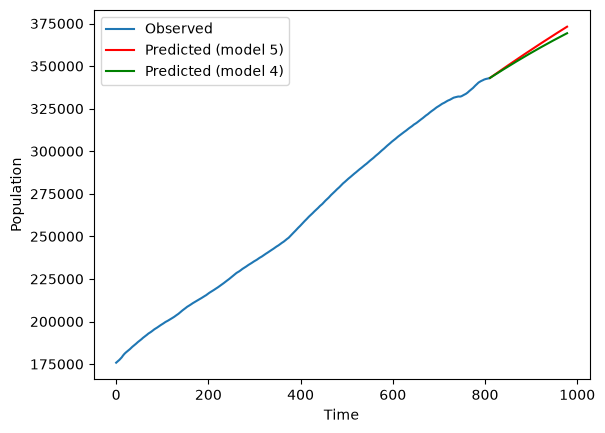

In [122]:
plt.plot(np.arange(n), y, label="Observed")
plt.plot(np.arange(n, n + 168), y_future_md5, label="Predicted (model 5)", color = 'red')
plt.plot(np.arange(n, n + 168), y_future_md4, label="Predicted (model 4)", color = 'green')


plt.xlabel("Time")
plt.ylabel("Population")
plt.legend()
plt.show()

Here is a plot of the growth rates along with the fitted values for Models 4 and 5. 

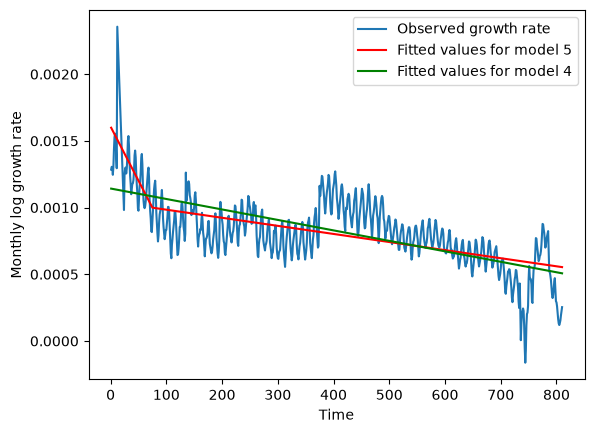

In [120]:
plt.plot(t, g, label="Observed growth rate")
plt.plot(t, md5.fittedvalues, label="Fitted values for model 5", color = 'red')
plt.plot(t, md4.fittedvalues, label="Fitted values for model 4", color = 'green')

plt.xlabel("Time")
plt.ylabel("Monthly log growth rate")
plt.legend()
plt.show()

It is clear that the fitted slope for Model 5 after the breakpoint is slightly higher than the overall slope obtained from Model 4. This is the reason why Model 5 is giving a slightly larger prediction for future values compared to Model 4. 

Below is the plot of residuals for Model 5. 

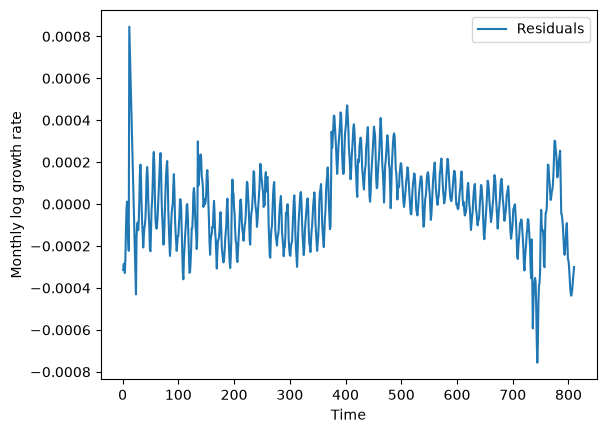

In [123]:
g_residuals = g - md5.fittedvalues
plt.plot(t, g_residuals, label="Residuals")
plt.xlabel("Time")
plt.ylabel("Monthly log growth rate")
plt.legend()
plt.show()

### Model 6: Two change of slope points

Next we fit a modification of Model 5 which has two change of slope points: 
\begin{align*}
   g_t = \beta_0 + + \beta_1 t + \beta_2 (t - c_1)_+ + \beta_3 (t - c_2)_+ + \epsilon_t. 
\end{align*}
This fits a curve with two different slopes. Assuming $c_1 < c_2$, the slopes are $\beta_1$ (before $c_1$), $\beta_1 + \beta_2$ (between $c_1$ and $c_2$) and $\beta_1 + \beta_2 + \beta_3$ after $c_2$. We will treat $c_1, c_2$ as unknown and estimate them from the data. We will go over the estimation strategy later in detail (essentially, we go over all values of $c_1, c_2$ and select the ones which give the smallest sum of squares); the code given below computes the estimates. 

In [124]:
# Growth rates
g = np.diff(ylog)
n_g = len(g)

t = np.arange(1, n_g + 1)

# Dates corresponding to the growth rates
growth_dates = y.index[1:]


# RSS for two change points c1 and c2
def rss(c1, c2):
    
    X = np.column_stack([
        np.ones(n_g),
        t,
        np.maximum(t - c1, 0),
        np.maximum(t - c2, 0)
    ])
    
    beta_hat = np.linalg.lstsq(X, g, rcond=None)[0]
    residuals = g - X @ beta_hat
    
    return np.sum(residuals ** 2)


# Possible change points
c_candidates = np.arange(12, n_g - 11)

# Grid search over all pairs
best_rss = np.inf

for c1 in c_candidates:
    for c2 in c_candidates:
        
        if c2 > c1:
            
            current_rss = rss(c1, c2)
            
            if current_rss < best_rss:
                best_rss = current_rss
                c1_hat = c1
                c2_hat = c2


print("Estimated change points:")
print(c1_hat, growth_dates[c1_hat - 1])
print(c2_hat, growth_dates[c2_hat - 1])

print("Minimum RSS:", best_rss)

Estimated change points:
108 1968-01-01 00:00:00
453 1996-10-01 00:00:00
Minimum RSS: 2.0261488639824974e-05


The estimated $c_1$ and $c_2$ are 108 (corresponding to January 1968) and 453 (corresponding to October 1996). With these values of $c_1$ and $c_2$, we can simply fit the model using linear regression (OLS) as before. 

In [125]:
X7 = np.column_stack([
    np.ones(n_g),
    t,
    np.maximum(t - c1_hat, 0),
    np.maximum(t - c2_hat, 0)
])

md7 = sm.OLS(g, X7).fit()

print(md7.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     537.7
Date:                Wed, 02 Sep 2026   Prob (F-statistic):          7.93e-192
Time:                        15:09:46   Log-Likelihood:                 5939.7
No. Observations:                 810   AIC:                        -1.187e+04
Df Residuals:                     806   BIC:                        -1.185e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016   2.76e-05     57.221      0.0

Predictions are obtained as follows. 

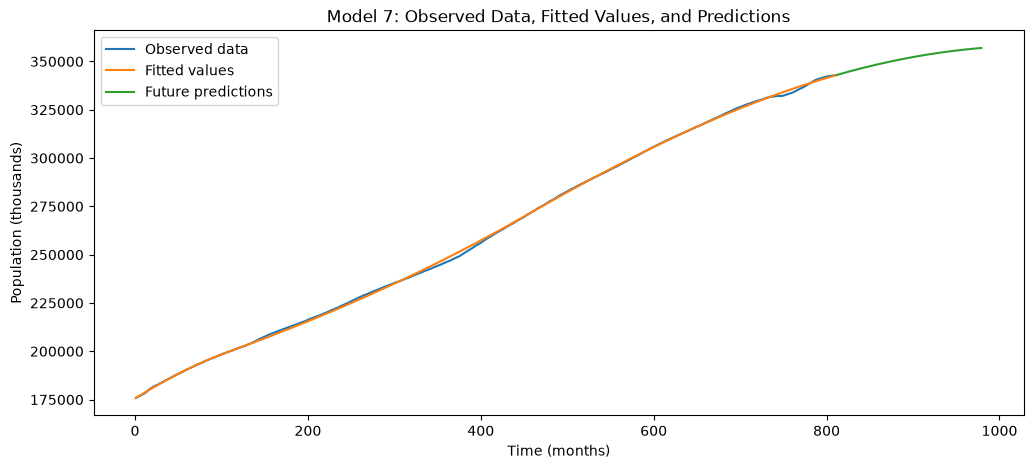

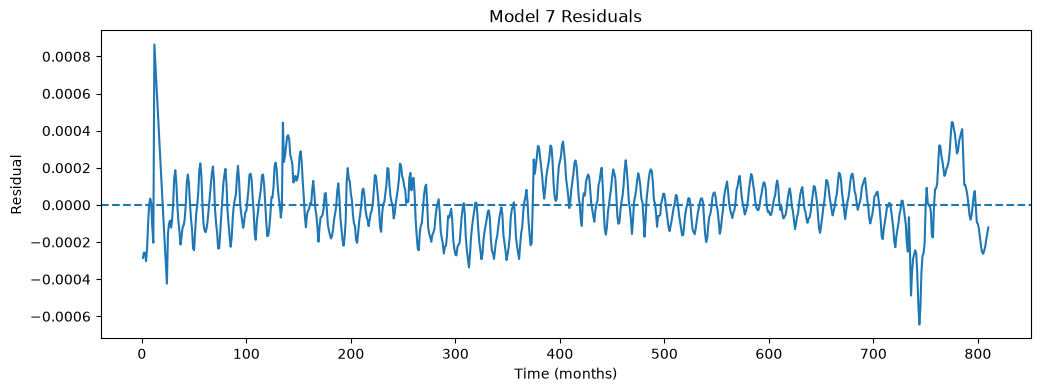

Prediction 168 months ahead: 356954.5625958116


In [126]:
# Fitted growth rates
g_fitted = md7.predict(X7)

# Convert fitted growth rates back to population
logy_fitted = np.r_[ylog.iloc[0], ylog.iloc[0] + np.cumsum(g_fitted)]
y_fitted = np.exp(logy_fitted)


# --------------------------------------------------
# Predict the next 168 months
# --------------------------------------------------

r = 168

t_future = np.arange(n_g + 1, n_g + r + 1)

X7_future = np.column_stack([
    np.ones(r),
    t_future,
    np.maximum(t_future - c1_hat, 0),
    np.maximum(t_future - c2_hat, 0)
])

# Predicted future growth rates
g_future = md7.predict(X7_future)

# Convert predicted growth rates to population
logy_future = ylog.iloc[-1] + np.cumsum(g_future)
y_future = np.exp(logy_future)


# --------------------------------------------------
# Plot population: data, fitted values, predictions
# --------------------------------------------------

x = np.arange(1, len(y) + 1)
x_future = np.arange(len(y) + 1, len(y) + r + 1)

plt.figure(figsize=(12, 5))

plt.plot(x, y, label="Observed data")
plt.plot(x, y_fitted, label="Fitted values")
plt.plot(x_future, y_future, label="Future predictions")

plt.xlabel("Time (months)")
plt.ylabel("Population (thousands)")
plt.title("Model 7: Observed Data, Fitted Values, and Predictions")
plt.legend()

plt.show()


# --------------------------------------------------
# Plot residuals
# --------------------------------------------------

residuals = md7.resid

plt.figure(figsize=(12, 4))

plt.plot(t, residuals)
plt.axhline(0, linestyle="--")

plt.xlabel("Time (months)")
plt.ylabel("Residual")
plt.title("Model 7 Residuals")

plt.show()


print("Prediction 168 months ahead:", y_future[-1])

The prediction for July 2040 given by this model is 356.954 million, which is quite close to the prediction given by the Census Bureau. 

Below is the plot for the growth rates along with the fitted regression curve. 

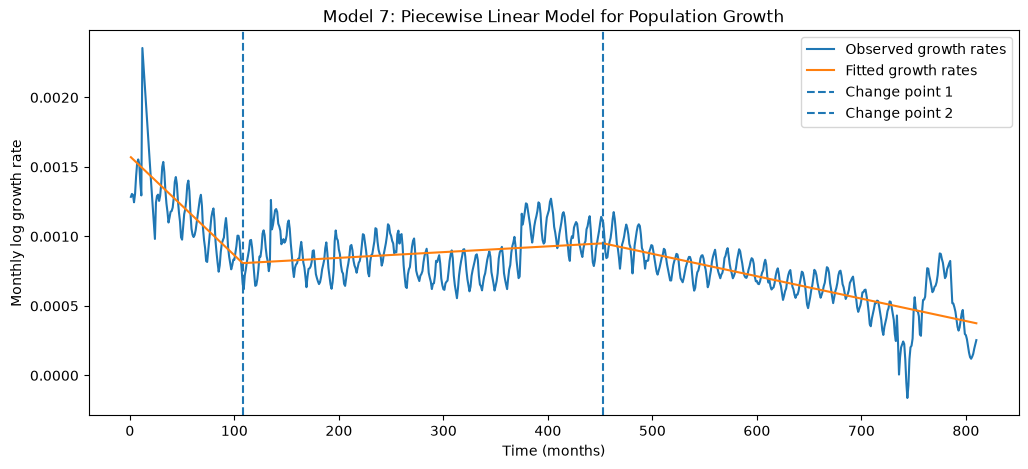

In [127]:
plt.figure(figsize=(12, 5))

plt.plot(t, g, label="Observed growth rates")
plt.plot(t, g_fitted, label="Fitted growth rates")

plt.axvline(c1_hat, linestyle="--", label="Change point 1")
plt.axvline(c2_hat, linestyle="--", label="Change point 2")

plt.xlabel("Time (months)")
plt.ylabel("Monthly log growth rate")
plt.title("Model 7: Piecewise Linear Model for Population Growth")
plt.legend()

plt.show()

This model fits a smaller slope for the data after time October 1996. This is the reason for its smaller prediction compared to the other models. 

Overall message from this notebook is that there are several ways of using linear regression for time series forecasting, and different models yield different predictions. The idea of working with **differenced** data is quite common in time series analysis, and yields good results often. Differencing means working with $x_t - x_{t-1}$ instead of $x_t$. In the above analysis, we worked with growth rates which are the result of differencing applied to $\log y_t$. We shall work with differenced data in many applications in this course. 